In [14]:
!pip install transformers torch feedparser praw

   ---------------------------------------- 0.0/189.3 kB ? eta -:--:--
   -- ------------------------------------- 10.2/189.3 kB ? eta -:--:--
   -- ------------------------------------- 10.2/189.3 kB ? eta -:--:--
   ------ -------------------------------- 30.7/189.3 kB 163.8 kB/s eta 0:00:01
   -------- ------------------------------ 41.0/189.3 kB 196.9 kB/s eta 0:00:01
   ------------ -------------------------- 61.4/189.3 kB 252.2 kB/s eta 0:00:01
   -------------- ------------------------ 71.7/189.3 kB 261.4 kB/s eta 0:00:01
   ------------------ -------------------- 92.2/189.3 kB 275.8 kB/s eta 0:00:01
   ------------------------ ------------- 122.9/189.3 kB 327.4 kB/s eta 0:00:01
   ---------------------------- --------- 143.4/189.3 kB 340.5 kB/s eta 0:00:01
   ------------------------------ ------- 153.6/189.3 kB 327.3 kB/s eta 0:00:01
   ---------------------------------- --- 174.1/189.3 kB 327.7 kB/s eta 0:00:01
   -------------------------------------- 189.3/189.3 kB 337.3 kB

In [27]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
import feedparser
import pandas as pd 
from transformers import AutoTokenizer,AutoModelForSequenceClassification
import torch 
from datetime import datetime,timedelta   
import matplotlib.pyplot as plt  

In [3]:
RSS_FEEDS={
    "coindesk":"https://www.coindesk.com/arc/outboundfeeds/rss/?outputType=xml",
    "cointelegraph":"https://cointelegraph.com/rss",
    "bitcoin_magazine":"https://bitcoinmagazine.com/.rss/full/",
    "decrypt":"https://decrypt.co/feed",
    "cryptoslate":"https://cryptoslate.com/feed/",
    "the_block":"https://www.theblockcrypto.com/feed/",
    "brave_new_coin":"https://bravenewcoin.com/news/rss",
    "newsbtc":"https://www.newsbtc.com/feed/",
    "bitcoinist":"https://bitcoinist.com/feed/",
    "crypto_briefing":"https://cryptobriefing.com/feed/",
    "coinjournal":"https://coinjournal.net/feed/",
    "cryptopotato":"https://cryptopotato.com/feed/",
    "financemagnates":"https://www.financemagnates.com/cryptocurrency/feed/",
    "bitcoin_core_announcements":"https://bitcoincore.org/en/announcements.xml",
    "ethereum_world_news":"https://ethereumworldnews.com/feed/",
    "kraken_blog":"https://blog.kraken.com/feed/"
}

In [4]:
def fetch_rss_articles(feed_dict,limit=50):
    all_articles=[]
    threshold=datetime.now()-timedelta(hours=12)
    for source,url in feed_dict.items():
        feed=feedparser.parse(url)
        for entry in feed.entries[:limit]:
            if hasattr(entry,'published_parsed') and entry.published_parsed:
                entry_date=datetime(*entry.published_parsed[:6])
            else:
                continue 
            if entry_date>=threshold:
                all_articles.append({
                    "source":source,
                    "title":entry.title,
                    "summary":entry.summary if "summary" else "",
                    "published":entry.get("published",None)
                })
    df=pd.DataFrame(all_articles)
    return df
df_news=fetch_rss_articles(RSS_FEEDS)
df_news

,source,title,summary,published
0,coindesk,"SEC, CFTC end years of rivalry with deal that ...",,"Wed, 11 Mar 2026 23:00:49 +0000"
1,coindesk,Crypto platform Bullish climbs past Coinbase t...,,"Wed, 11 Mar 2026 20:33:01 +0000"
2,coindesk,"Bitcoin holds $70,000, starting to show relati...",,"Wed, 11 Mar 2026 20:23:58 +0000"
3,coindesk,Ripple's share buyback program values the firm...,,"Wed, 11 Mar 2026 19:19:10 +0000"
4,cointelegraph,Here’s what happened in crypto today,"<p style=""float: right; margin: 0 0 10px 15px;...","Wed, 11 Mar 2026 21:56:54 +0000"
5,cointelegraph,Ripple to buy back $750M in shares through Apr...,"<p style=""float: right; margin: 0 0 10px 15px;...","Wed, 11 Mar 2026 21:19:53 +0000"
6,cointelegraph,Mastercard launches crypto partner program wit...,"<p style=""float: right; margin: 0 0 10px 15px;...","Wed, 11 Mar 2026 20:52:19 +0000"
7,cointelegraph,"Revolut obtains UK bank license, teases upcomi...","<p style=""float: right; margin: 0 0 10px 15px;...","Wed, 11 Mar 2026 20:19:06 +0000"
8,cointelegraph,Bitcoin to $78K? Pro traders price in less tha...,"<p style=""float: right; margin: 0 0 10px 15px;...","Wed, 11 Mar 2026 20:00:00 +0000"
9,cointelegraph,FDIC chair says no deposit insurance for stabl...,"<p style=""float: right; margin: 0 0 10px 15px;...","Wed, 11 Mar 2026 19:37:15 +0000"


In [4]:
MODEL_NAME="ProsusAI/finbert"
tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME)
model=AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
labels=["negative","neutral","positive"]
def finbert_sentiment(text):
    inputs=tokenizer(text[:512],return_tensors="pt",truncation=True)
    outputs=model(**inputs)
    probs=torch.nn.functional.softmax(outputs.logits,dim=1)
    score,pred=torch.max(probs,dim=1)
    return labels[pred.item()],score.item()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
df_news["text"]=df_news["title"]+" "+df_news["summary"]
sentiments=df_news["text"].apply(finbert_sentiment)
df_news["sentiment"]=sentiments.apply(lambda x:x[0])
df_news["confidence"]=sentiments.apply(lambda x:x[1])
df_news.head()

,source,title,summary,published,text,sentiment,confidence
0,coindesk,Bitcoin dip may not be over as whales sell int...,,"Sun, 08 Mar 2026 05:16:45 +0000",Bitcoin dip may not be over as whales sell int...,neutral,0.848329
1,coindesk,XRP slips as traders watch $1.35 support,,"Sun, 08 Mar 2026 05:06:07 +0000",XRP slips as traders watch $1.35 support,neutral,0.904029
2,newsbtc,"Pundit Says XRP Price Could Reach $1,000 By En...",The possibility of a massive surge in the XRP ...,"Sun, 08 Mar 2026 00:30:47 +0000","Pundit Says XRP Price Could Reach $1,000 By En...",positive,0.787837
3,newsbtc,Here’s Why Bitcoin Price Must Not Fall To $54K...,"Over the past few days, the Bitcoin price has ...","Sat, 07 Mar 2026 23:30:34 +0000",Here’s Why Bitcoin Price Must Not Fall To $54K...,negative,0.568170
4,bitcoinist,"Satoshi Nakamoto’s Bitcoin Could Get Stolen, B...",Satoshi Nakamoto’s Bitcoin holdings risk getti...,"Sun, 08 Mar 2026 05:00:06 +0000","Satoshi Nakamoto’s Bitcoin Could Get Stolen, B...",positive,0.658061


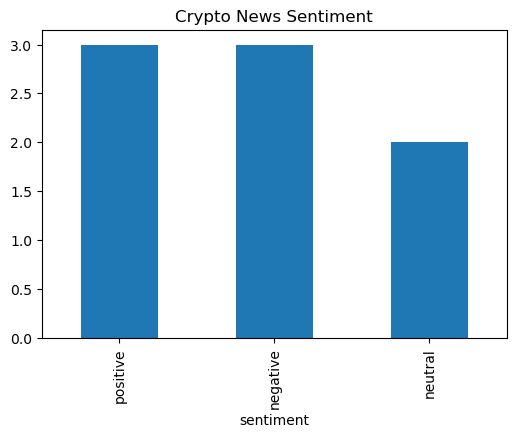

In [6]:
sent_counts=df_news["sentiment"].value_counts()
plt.figure(figsize=(6,4))
sent_counts.plot(kind="bar")
plt.title("Crypto News Sentiment")
plt.show()

In [7]:
df_news['score']=df_news['sentiment'].map({
    'positive':1,
    'neutral':0,
    'negative':-1
})
daily_sentiment=df_news['score'].mean()
daily_sentiment

0.0